In [1]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json
import os
import time
url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
#Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
parameters = {
  'start':'1',
  'limit':'15',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': 'YOUR_API_KEY_HERE',
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)

{'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'infinite_supply': False, 'circulating_supply': 20035928, 'total_supply': 20035928, 'max_supply': 21000000, 'date_added': '2010-07-13T00:00:00.000Z', 'num_market_pairs': 12648, 'cmc_rank': 1, 'last_updated': '2026-05-29T03:06:00.000Z', 'tvl_ratio': None, 'platform': None, 'self_reported_circulating_supply': None, 'self_reported_market_cap': None, 'minted_market_cap': 1466756778681.42, 'quote': {'USD': {'price': 73206.3310809171, 'volume_24h': 38975521259.44946, 'cex_volume_24h': 38952372017.52433, 'dex_volume_24h': 23149241.9251303, 'volume_change_24h': 12.8521, 'percent_change_1h': -0.39606673, 'percent_change_24h': -1.36299797, 'percent_change_7d': -5.74321812, 'percent_change_30d': -4.34225505, 'percent_change_60d': 9.28443189, 'percent_change_90d': 11.11069167, 'market_cap': 1466756778681.4172, 'market_cap_dominance': 59.6458, 'fully_diluted_market_cap': 1537332952699.26, 'tvl': None, 'last_updated': '2026-0

In [2]:
type(data)

dict

In [3]:
import pandas as pd

pd.set_option('display.max_columns', None)

In [4]:
df = pd.json_normalize(data['data'])
df['timestamp'] = pd.to_datetime('now')
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.003593e+07,2.003593e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12648,1,2026-05-29T03:06:00.000Z,None,NaN,NaN,NaN,1.466757e+12,"[mineable, pow, sha-256, store-of-value, state...",73206.331081,3.897552e+10,3.895237e+10,2.314924e+07,12.8521,-0.396067,-1.362998,-5.743218,-4.342255,9.284432,11.110692,1.466757e+12,59.6458,1.537333e+12,None,2026-05-29T03:06:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-29 06:08:43.293421
1,1027,Ethereum,ETH,ethereum,True,1.206853e+08,1.206853e+08,NaN,2015-08-07T00:00:00.000Z,12010,2,2026-05-29T03:06:00.000Z,None,NaN,NaN,NaN,2.412885e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",1999.318976,1.741657e+10,1.728823e+10,1.283425e+08,16.7013,-0.376911,-0.839809,-6.464607,-12.638031,-1.412077,3.687316,2.412885e+11,9.8100,2.412885e+11,None,2026-05-29T03:06:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-29 06:08:43.293421
2,825,Tether USDt,USDT,tether,True,1.895827e+11,1.931898e+11,NaN,2015-02-25T00:00:00.000Z,183468,3,2026-05-29T03:06:00.000Z,None,NaN,NaN,NaN,1.929260e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.998634,8.438872e+10,8.263804e+10,1.750686e+09,10.0325,0.003956,0.012263,-0.041542,-0.126694,-0.068615,-0.134240,1.893238e+11,7.6981,1.929260e+11,None,2026-05-29T03:06:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-29 06:08:43.293421
3,1839,BNB,BNB,bnb,False,1.347847e+08,1.347847e+08,1.347847e+08,2017-07-25T00:00:00.000Z,3258,4,2026-05-29T03:07:00.000Z,None,NaN,NaN,NaN,8.548771e+10,"[marketplace, centralized-exchange, payments, ...",634.253804,1.356511e+09,1.325790e+09,3.072109e+07,7.4654,-0.338465,-1.583772,-3.932436,1.622608,3.064218,3.178699,8.548771e+10,3.4775,8.548771e+10,None,2026-05-29T03:07:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-29 06:08:43.293421
4,52,XRP,XRP,xrp,False,6.197784e+10,9.998566e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1837,5,2026-05-29T03:06:00.000Z,None,NaN,NaN,NaN,1.303778e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.303965,2.444658e+09,2.443115e+09,1.542764e+06,23.8683,-0.374900,0.315593,-4.957915,-5.488165,-3.110117,-4.123315,8.081691e+10,3.2864,1.303965e+11,None,2026-05-29T03:06:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-29 06:08:43.293421
5,3408,USDC,USDC,usd-coin,False,7.624476e+10,7.624476e+10,NaN,2018-10-08T00:00:00.000Z,39950,6,2026-05-29T03:06:00.000Z,None,NaN,6.090122e+10,6.088530e+10,7.622483e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999739,1.259334e+10,9.878741e+09,2.714602e+09,-9.6847,0.012556,0.023464,-0.002713,-0.021791,-0.015743,-0.028868,7.622483e+10,3.0997,7.622483e+10,None,2026-05-29T03:06:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-05-29 06:08:43.293421
6,5426,Solana,SOL,solana,True,5.783343e+08,6.272672e+08,NaN,2020-04-10T00:00:00.000Z,1137,7,2026-05-29T03:06:00.000Z,None,NaN,5.252369e+08,4.281972e+10,5.113770e+10,"[pos, platform, solana-ecosystem, cms-holdings...",81.524586,3.507799e+09,3.507789e+09,9.612838e+03,1.7109,-0.752781,-0.557063,-6.435215,-3.028545,-1.978337,-0.614184,4.714847e+10,1.9173,5.113770e+10,None,2026-05-29T03:06:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-29 06:08:43.293421
7,1958,TRON,TRX,tron,True,9.481238e+10,9.481237e+10,NaN,2017-09-13T00:00:00.000Z,1347,8,2026-05-29T03:07:00.000Z,None,NaN,9.

In [5]:
def api_runner():
    global df
    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
    #Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
    parameters = {
      'start':'1',
      'limit':'15',
      'convert':'USD'
    }
    headers = {
      'Accepts': 'application/json',
      'X-CMC_PRO_API_KEY': 'YOUR_API_KEY_HERE',
    }

    session = Session()
    session.headers.update(headers)

    try:
      response = session.get(url, params=parameters)
      data = json.loads(response.text)
      #print(data)
    except (ConnectionError, Timeout, TooManyRedirects) as e:
      print(e)
    
    df = pd.json_normalize(data['data'])
    df['timestamp'] = pd.to_datetime('now')
    df

    if not os.path.isfile(r'C:\Users\astrr\OneDrive\Desktop\Data Analyst bootcamp\Crypto project\API.csv'):
        df.to_csv(r'C:\Users\astrr\OneDrive\Desktop\Data Analyst bootcamp\Crypto project\API.csv', header='column_names')
    else:
        df.to_csv(r'C:\Users\astrr\OneDrive\Desktop\Data Analyst bootcamp\Crypto project\API.csv', mode='a', header=False)

In [6]:
import os
from time import time
from time import sleep

for i in range(20):
    api_runner()
    print(f'API Runner completed {i + 1} times')
    sleep(30)
print("Finished")

API Runner completed 1 times
API Runner completed 2 times
API Runner completed 3 times
API Runner completed 4 times
API Runner completed 5 times
Finished


In [7]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.003593e+07,2.003593e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12648,1,2026-05-29T03:07:00.000Z,None,NaN,NaN,NaN,1.467052e+12,"[mineable, pow, sha-256, store-of-value, state...",73221.062937,3.921292e+10,3.918990e+10,2.302264e+07,13.2666,-0.363024,-1.338329,-5.723299,-4.339141,9.295113,11.155874,1.467052e+12,59.6578,1.537642e+12,None,2026-05-29T03:07:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-29 06:09:11.253469
1,1027,Ethereum,ETH,ethereum,True,1.206853e+08,1.206853e+08,NaN,2015-08-07T00:00:00.000Z,12010,2,2026-05-29T03:08:00.000Z,None,NaN,NaN,NaN,2.415175e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",2001.216442,1.747060e+10,1.733834e+10,1.322558e+08,17.1661,-0.270912,-0.747737,-6.354395,-12.575811,-1.339671,3.785435,2.415175e+11,9.8193,2.415175e+11,None,2026-05-29T03:08:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-29 06:09:11.253469
2,825,Tether USDt,USDT,tether,True,1.895827e+11,1.931898e+11,NaN,2015-02-25T00:00:00.000Z,183468,3,2026-05-29T03:07:00.000Z,None,NaN,NaN,NaN,1.929189e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.998598,8.440216e+10,8.264887e+10,1.753292e+09,9.9815,0.002586,0.024316,-0.045388,-0.132249,-0.074606,-0.138042,1.893169e+11,7.6978,1.929189e+11,None,2026-05-29T03:07:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-29 06:09:11.253469
3,1839,BNB,BNB,bnb,False,1.347847e+08,1.347847e+08,1.347847e+08,2017-07-25T00:00:00.000Z,3258,4,2026-05-29T03:07:00.000Z,None,NaN,NaN,NaN,8.548771e+10,"[marketplace, centralized-exchange, payments, ...",634.253804,1.356511e+09,1.325790e+09,3.072109e+07,7.4654,-0.338465,-1.583772,-3.932436,1.622608,3.064218,3.178699,8.548771e+10,3.4775,8.548771e+10,None,2026-05-29T03:07:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-29 06:09:11.253469
4,52,XRP,XRP,xrp,False,6.197784e+10,9.998566e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1837,5,2026-05-29T03:08:00.000Z,None,NaN,NaN,NaN,1.305403e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.305590,2.445637e+09,2.444094e+09,1.543094e+06,23.8281,-0.257299,0.393934,-4.835560,-5.376091,-2.987640,-4.004034,8.091767e+10,3.2905,1.305590e+11,None,2026-05-29T03:08:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-29 06:09:11.253469
5,3408,USDC,USDC,usd-coin,False,7.624476e+10,7.624476e+10,NaN,2018-10-08T00:00:00.000Z,39950,6,2026-05-29T03:07:00.000Z,None,NaN,6.090122e+10,6.087721e+10,7.621470e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999606,1.259929e+10,9.886634e+09,2.712655e+09,-9.6658,0.001813,0.002041,-0.015613,-0.038018,-0.026101,-0.037273,7.621470e+10,3.0993,7.621470e+10,None,2026-05-29T03:07:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-05-29 06:09:11.253469
6,5426,Solana,SOL,solana,True,5.783343e+08,6.272672e+08,NaN,2020-04-10T00:00:00.000Z,1137,7,2026-05-29T03:07:00.000Z,None,NaN,5.252369e+08,4.285475e+10,5.117954e+10,"[pos, platform, solana-ecosystem, cms-holdings...",81.591283,3.507870e+09,3.507860e+09,9.612489e+03,1.6729,-0.678407,-0.513331,-6.358054,-2.965841,-1.913572,-0.524416,4.718704e+10,1.9189,5.117954e+10,None,2026-05-29T03:07:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-29 06:09:11.253469
7,1958,TRON,TRX,tron,True,9.481238e+10,9.481237e+10,NaN,2017-09-13T00:00:00.000Z,1347,8,2026-05-29T03:08:00.000Z,None,NaN,9.4

In [8]:
df3 = pd.read_csv(r'C:\Users\astrr\OneDrive\Desktop\Data Analyst bootcamp\Crypto project\API.csv')
df3

,Unnamed: 0,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,Timestamp
0,0,1,Bitcoin,BTC,bitcoin,False,2.003587e+07,2.003587e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12648,1,2026-05-29T00:36:00.000Z,NaN,NaN,NaN,NaN,1.476490e+12,"['mineable', 'pow', 'sha-256', 'store-of-value...",73692.095170,3.993105e+10,3.990476e+10,2.628542e+07,18.8887,0.169479,-0.996366,-4.873190,-3.413081,10.849816,11.975196,1.476490e+12,59.6287,1.547530e+12,NaN,2026-05-29T00:36:00.000Z,NaN,NaN,NaN,NaN,NaN,38:33.8
1,1,1027,Ethereum,ETH,ethereum,True,1.206854e+08,1.206854e+08,NaN,2015-08-07T00:00:00.000Z,12010,2,2026-05-29T00:36:00.000Z,NaN,NaN,NaN,NaN,2.427910e+11,"['pos', 'smart-contracts', 'ethereum-ecosystem...",2011.771222,1.783438e+10,1.771304e+10,1.213465e+08,23.3007,0.219092,-0.609240,-5.653379,-11.976771,0.375470,4.363196,2.427910e+11,9.8053,2.427910e+11,NaN,2026-05-29T00:36:00.000Z,NaN,NaN,NaN,NaN,NaN,38:33.8
2,2,825,Tether USDt,USDT,tether,True,1.895830e+11,1.931900e+11,NaN,2015-02-25T00:00:00.000Z,183467,3,2026-05-29T00:36:00.000Z,NaN,NaN,NaN,NaN,1.929480e+11,"['stablecoin', 'asset-backed-stablecoin', 'usd...",0.998746,8.534734e+10,8.360418e+10,1.743157e+09,13.2608,0.014804,0.032192,-0.048512,-0.106953,-0.070494,-0.121460,1.893450e+11,7.6468,1.929480e+11,NaN,2026-05-29T00:36:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,38:33.8
3,3,1839,BNB,BNB,bnb,False,1.347847e+08,1.347847e+08,1.347847e+08,2017-07-25T00:00:00.000Z,3258,4,2026-05-29T00:36:00.000Z,NaN,NaN,NaN,NaN,8.600092e+10,"['marketplace', 'centralized-exchange', 'payme...",638.061426,1.378513e+09,1.347747e+09,3.076660e+07,6.9691,-0.053385,-1.429947,-3.010566,2.287214,4.476975,4.123421,8.600092e+10,3.4723,8.600092e+10,NaN,2026-05-29T00:36:00.000Z,NaN,NaN,NaN,NaN,NaN,38:33.8
4,4,52,XRP,XRP,xrp,False,6.197784e+10,9.998566e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1837,5,2026-05-29T00:37:00.000Z,NaN,NaN,NaN,NaN,1.315740e+11,"['medium-of-exchange', 'enterprise-solutions',...",1.315933,2.536748e+09,2.534960e+09,1.788132e+06,34.6028,0.079332,0.581344,-3.878000,-4.585577,-1.419470,-3.191787,8.155871e+10,3.2938,1.315930e+11,NaN,2026-05-29T00:37:00.000Z,NaN,NaN,NaN,NaN,NaN,38:33.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,10,3957,UNUS SED LEO,LEO,unus-sed-leo,False,9.205282e+08,9.852395e+08,NaN,2019-05-21T00:00:00.000Z,68,11,2026-05-29T03:08:00.000Z,NaN,NaN,NaN,NaN,9.805405e+09,"['marketplace', 'centralized-exchange', 'disco...",9.952306,1.313251e+06,1.313251e+06,0.000000e+00,340.8799,0.046474,-1.009056,-0.422693,-4.007112,2.759767,12.724872,9.161379e+09,0.3725,9.805405e+09,NaN,2026-05-29T03:08:00.000Z,1027.0,ethereum,Ethereum,ETH,0x2af5d2ad76741191d15dfe7bf6ac92d4bd912ca3,2026-05-29 06:09:11.253469
236,11,1437,Zcash,ZEC,zcash,False,1.669794e+07,1.669794e+07,2.100000e+07,2016-10-29T00:00:00.000Z,616,12,2026-05-29T03:07:00.000Z,NaN,NaN,NaN,NaN,9.065769e+09,"['mineable', 'pow', 'equihash', 'medium-of-exc...",542.927309,7.671608e+08,7.468572e+08,2.030360e+07,-0.7053,-1.264831,0.136553,-17.634449,61.794701,145.812338,144.977491,9.065769e+09,0.3688,1.140147e+10,NaN,2026-05-29T03:07:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-29 06:09:11.253469
237,12,2010,Cardano,ADA,cardano,False,3.621805e+10,

In [9]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [10]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,20035928.00000,20035928.00000,21000000.00000,2010-07-13T00:00:00.000Z,12648,1,2026-05-29T03:07:00.000Z,None,NaN,NaN,NaN,1467051945092.02002,"[mineable, pow, sha-256, store-of-value, state...",73221.06294,39212923877.56877,39189901239.94162,23022637.62714,13.26660,-0.36302,-1.33833,-5.72330,-4.33914,9.29511,11.15587,1467051945092.01709,59.65780,1537642321679.94995,None,2026-05-29T03:07:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-29 06:09:11.253469
1,1027,Ethereum,ETH,ethereum,True,120685349.60092,120685349.60092,NaN,2015-08-07T00:00:00.000Z,12010,2,2026-05-29T03:08:00.000Z,None,NaN,NaN,NaN,241517505870.00000,"[pos, smart-contracts, ethereum-ecosystem, coi...",2001.21644,17470600400.74600,17338344638.70993,132255762.03606,17.16610,-0.27091,-0.74774,-6.35440,-12.57581,-1.33967,3.78543,241517505870.00320,9.81930,241517505870.00000,None,2026-05-29T03:08:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-29 06:09:11.253469
2,825,Tether USDt,USDT,tether,True,189582683099.13315,193189782102.15887,NaN,2015-02-25T00:00:00.000Z,183468,3,2026-05-29T03:07:00.000Z,None,NaN,NaN,NaN,192918946109.70001,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.99860,84402157895.82161,82648866048.89703,1753291846.92458,9.98150,0.00259,0.02432,-0.04539,-0.13225,-0.07461,-0.13804,189316903959.20566,7.69780,192918946109.70001,None,2026-05-29T03:07:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-29 06:09:11.253469
3,1839,BNB,BNB,bnb,False,134784694.17000,134784694.17000,134784694.17000,2017-07-25T00:00:00.000Z,3258,4,2026-05-29T03:07:00.000Z,None,NaN,NaN,NaN,85487705018.21001,"[marketplace, centralized-exchange, payments, ...",634.25380,1356511338.21779,1325790249.97206,30721088.24573,7.46540,-0.33846,-1.58377,-3.93244,1.62261,3.06422,3.17870,85487705018.20714,3.47750,85487705018.21001,None,2026-05-29T03:07:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-29 06:09:11.253469
4,52,XRP,XRP,xrp,False,61977843307.00000,99985656462.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1837,5,2026-05-29T03:08:00.000Z,None,NaN,NaN,NaN,130540309357.61000,"[medium-of-exchange, enterprise-solutions, xrp...",1.30559,2445636924.48528,2444093830.55142,1543093.93386,23.82810,-0.25730,0.39393,-4.83556,-5.37609,-2.98764,-4.00403,80917674843.57401,3.29050,130559036142.57001,None,2026-05-29T03:08:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-29 06:09:11.253469
5,3408,USDC,USDC,usd-coin,False,76244763100.59663,76244763100.59663,NaN,2018-10-08T00:00:00.000Z,39950,6,2026-05-29T03:07:00.000Z,None,NaN,60901219650.23000,60877206871.82195,76214700507.24001,"[medium-of-exchange, stablecoin, asset-backed-...",0.99961,12599289256.78347,9886634145.93799,2712655110.84551,-9.66580,0.00181,0.00204,-0.01561,-0.03802,-0.02610,-0.03727,76214700507.24261,3.09930,76214700507.24001,None,2026-05-29T03:07:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-05-29 06:09:11.253469
6,5426,Solana,SOL,solana,True,578334327.78484,627267203.38106,NaN,2020-04-10T00:00:00.000Z,1137,7,2026-05-29T03:07:00.000Z,None,NaN,525236893.30000,42854752102.52038,51179536026.20000,"[pos, platform, solana-ecosystem, cms-holdings...",81.59128,3507869620.21148,3507860007.72277,9612.48871,1.67290,-0.67841,-0.51333,-6.35805,-2.96584,-1.91357,-0.

In [11]:
df4 = df.groupby('name', sort=False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d', 'quote.USD.percent_change_60d', 'quote.USD.percent_change_90d']].mean()
df4

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,-0.36302,-1.33833,-5.72330,-4.33914,9.29511,11.15587
Ethereum,-0.27091,-0.74774,-6.35440,-12.57581,-1.33967,3.78543
Tether USDt,0.00259,0.02432,-0.04539,-0.13225,-0.07461,-0.13804
BNB,-0.33846,-1.58377,-3.93244,1.62261,3.06422,3.17870
XRP,-0.25730,0.39393,-4.83556,-5.37609,-2.98764,-4.00403
USDC,0.00181,0.00204,-0.01561,-0.03802,-0.02610,-0.03727
Solana,-0.67841,-0.51333,-6.35805,-2.96584,-1.91357,-0.52442
TRON,-0.05070,-4.36487,-3.47929,9.08474,8.96892,24.25779
Hyperliquid,-1.80095,4.27266,5.46146,51.27865,58.01539,124.95813


In [12]:
df5 = df4.stack()
df5

name                                 
Bitcoin  quote.USD.percent_change_1h    -0.36302
         quote.USD.percent_change_24h   -1.33833
         quote.USD.percent_change_7d    -5.72330
         quote.USD.percent_change_30d   -4.33914
         quote.USD.percent_change_60d    9.29511
                                          ...   
Monero   quote.USD.percent_change_24h   -8.27274
         quote.USD.percent_change_7d    -6.38194
         quote.USD.percent_change_30d   -5.90887
         quote.USD.percent_change_60d    8.49238
         quote.USD.percent_change_90d    5.64645
Length: 90, dtype: float64

In [13]:
type(df4)

pandas.core.frame.DataFrame

In [14]:
type(df5)

pandas.core.series.Series

In [15]:
df6 = df5.to_frame(name='values')
df6

values
name                                         
Bitcoin quote.USD.percent_change_1h  -0.36302
        quote.USD.percent_change_24h -1.33833
        quote.USD.percent_change_7d  -5.72330
        quote.USD.percent_change_30d -4.33914
        quote.USD.percent_change_60d  9.29511
...                                       ...
Monero  quote.USD.percent_change_24h -8.27274
        quote.USD.percent_change_7d  -6.38194
        quote.USD.percent_change_30d -5.90887
        quote.USD.percent_change_60d  8.49238
        quote.USD.percent_change_90d  5.64645

[90 rows x 1 columns]

In [16]:
df6.count()

values    90
dtype: int64

In [17]:
index = pd.Index(range(90))

df7 = df6.reset_index()
df7

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,-0.36302
1,Bitcoin,quote.USD.percent_change_24h,-1.33833
2,Bitcoin,quote.USD.percent_change_7d,-5.72330
3,Bitcoin,quote.USD.percent_change_30d,-4.33914
4,Bitcoin,quote.USD.percent_change_60d,9.29511
...,...,...,...
85,Monero,quote.USD.percent_change_24h,-8.27274
86,Monero,quote.USD.percent_change_7d,-6.38194
87,Monero,quote.USD.percent_change_30d,-5.90887
88,Monero,quote.USD.percent_change_60d,8.49238


In [18]:
df8 = df7.rename(columns={'level_1': 'percent_change'})

df8

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,-0.36302
1,Bitcoin,quote.USD.percent_change_24h,-1.33833
2,Bitcoin,quote.USD.percent_change_7d,-5.72330
3,Bitcoin,quote.USD.percent_change_30d,-4.33914
4,Bitcoin,quote.USD.percent_change_60d,9.29511
...,...,...,...
85,Monero,quote.USD.percent_change_24h,-8.27274
86,Monero,quote.USD.percent_change_7d,-6.38194
87,Monero,quote.USD.percent_change_30d,-5.90887
88,Monero,quote.USD.percent_change_60d,8.49238


In [19]:
df8['percent_change'] = df8['percent_change'].replace(['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['1h','24h','7d','30d','60d','90d'])
df8

,name,percent_change,values
0,Bitcoin,1h,-0.36302
1,Bitcoin,24h,-1.33833
2,Bitcoin,7d,-5.72330
3,Bitcoin,30d,-4.33914
4,Bitcoin,60d,9.29511
...,...,...,...
85,Monero,24h,-8.27274
86,Monero,7d,-6.38194
87,Monero,30d,-5.90887
88,Monero,60d,8.49238


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

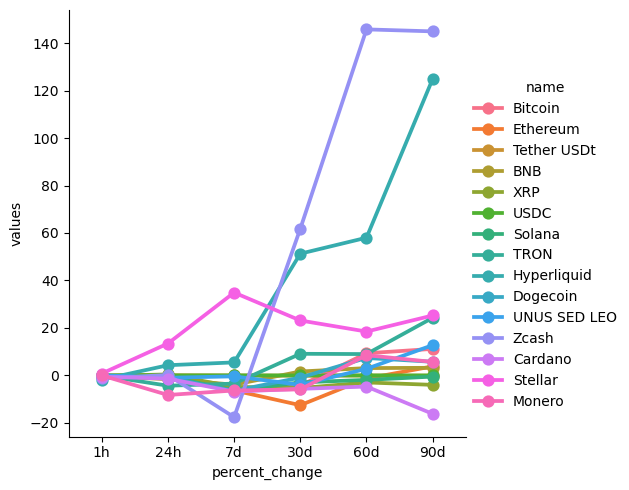

In [21]:
sns.catplot(x='percent_change', y='values', hue='name', data=df8, kind='point')

In [22]:
df10 = df[['name','quote.USD.price','timestamp']]
df10 = df10.query("name == 'Bitcoin'")
df10

,name,quote.USD.price,timestamp
0,Bitcoin,73221.06294,2026-05-29 06:09:11.253469


<Axes: xlabel='timestamp', ylabel='quote.USD.price'>

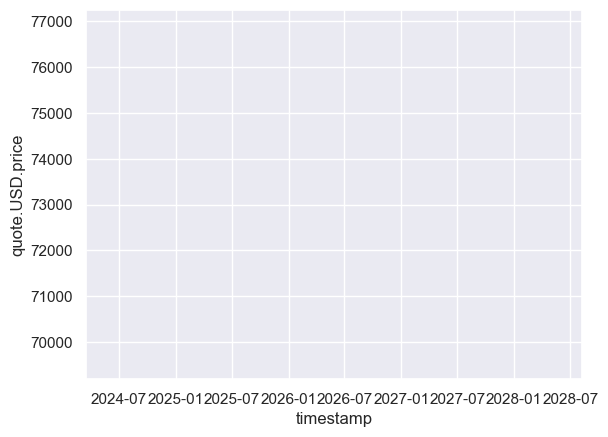

In [26]:
sns.set_theme(style="darkgrid")

sns.lineplot(x='timestamp', y='quote.USD.price', data=df10)

In [24]:
print(df10.shape)     # how many rows
print(df10.head())    # see the actual values

(1, 3)
      name  quote.USD.price                  timestamp
0  Bitcoin      73221.06294 2026-05-29 06:09:11.253469
